## Execution record

Full configured training run on 3 October 2026. The original epoch counts and model sizes were retained. Outputs below are from execution in this session. External services and audio playback may be skipped with an explicit reason.


# My MNIST classifier

I use this notebook to compare a dense network with a convolutional network on handwritten digits. I start with the data shapes then build the models and inspect their mistakes. This is my working adaptation of the MIT Introduction to Deep Learning lab. The course provides the starting code and helpers. These notes explain the choices in this version.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchsummary import summary

# MIT introduction to deep learning package
%pip install "setuptools<81" --quiet
%pip install mitdeeplearning --no-deps --no-build-isolation --quiet
import mitdeeplearning as mdl

import matplotlib.pyplot as plt
import numpy as np
import random
from tqdm import tqdm


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


C:\Users\Somil Singh\Documents\Codex\2026-10-03\new-chat\work\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
import os
import random
torch.manual_seed(7)
np.random.seed(7)
random.seed(7)
torch.set_num_threads(4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Runtime:", device)
class LocalExperiment:
    """I retain metrics locally so a notebook run needs no service account."""
    def __init__(self):
        self.metrics = {}
        self.parameters = {}
    def log_parameter(self, name, value):
        self.parameters[name] = value
    def log_metric(self, name, value, step=None):
        self.metrics.setdefault(name, []).append(float(value))
    def log_figure(self, figure=None):
        pass
    def log_asset(self, path):
        pass
    def flush(self):
        pass
    def end(self):
        print("Recorded metrics:", {k: v[-1] for k, v in self.metrics.items()})


Runtime: cuda


In [3]:
comet_model_1 = LocalExperiment()


## Loading MNIST

I keep the 60,000 training images separate from the 10,000 test images. ToTensor scales the grayscale values to the interval from zero to one.

In [4]:
# Download and transform the MNIST dataset
transform = transforms.Compose([
    # Convert images to PyTorch tensors which also scales data from [0,255] to [0,1]
    transforms.ToTensor()
])

# Download training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


  0%|          | 0.00/9.91M [00:00<?, ?B/s]


  0%|          | 32.8k/9.91M [00:00<01:11, 139kB/s]


  1%|          | 98.3k/9.91M [03:11<5:53:40, 462B/s]


  3%|▎         | 262k/9.91M [03:11<1:35:41, 1.68kB/s]


  4%|▍         | 426k/9.91M [03:12<46:20, 3.41kB/s]  


...

 78%|███████▊  | 1.28M/1.65M [00:02<00:00, 689kB/s]


 91%|█████████▏| 1.51M/1.65M [00:02<00:00, 754kB/s]


100%|██████████| 1.65M/1.65M [00:02<00:00, 700kB/s]


  0%|          | 0.00/4.54k [00:00<?, ?B/s]


100%|██████████| 4.54k/4.54k [00:00<00:00, 8.47MB/s]


I treat the dataset as a collection of image and label pairs. A DataLoader assembles those pairs into batches so I can train without holding a separate copy of every image.

In [5]:
image, label = train_dataset[0]
print(image.size())  # For a tensor: torch.Size([1, 28, 28])
print(label)  # For a label: integer (e.g., 5)


torch.Size([1, 28, 28])
5


I inspect a small grid before training. Each image should have one channel and a height and width of 28. Checking the labels here makes data mistakes easier to spot.

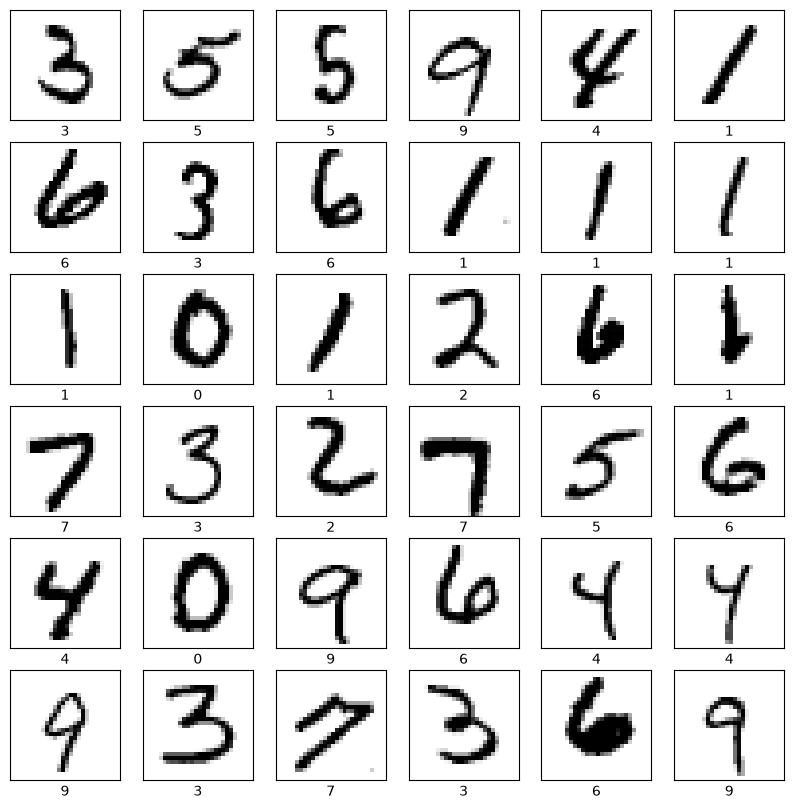

In [6]:
plt.figure(figsize=(10,10))
random_inds = np.random.choice(60000,36)
for i in range(36):
    plt.subplot(6, 6, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    image_ind = random_inds[i]
    image, label = train_dataset[image_ind]
    plt.imshow(image.squeeze(), cmap=plt.cm.binary)
    plt.xlabel(label)
comet_model_1.log_figure(figure=plt)


## My dense baseline

I flatten each image into 784 features and pass it through a hidden layer with 128 units. The final layer returns ten logits. CrossEntropyLoss expects those raw scores so I leave softmax out of the model.

In [7]:
def build_fc_model():
    fc_model = nn.Sequential(
        # First define a Flatten layer
        nn.Flatten(),

        # Activation function for the first fully connected (Dense/Linear) layer.
        nn.Linear(28 * 28, 128),
        nn.ReLU(),

        # Second Linear layer to output the classification probabilities
        nn.Linear(128, 10)
    )
    return fc_model

fc_model_sequential = build_fc_model()


### My note on flattening

Flattening preserves the pixel values and their fixed positions but gives the model no built in preference for neighbouring pixels. That is the advantage I want to test with convolutions.

In [8]:
# Define the fully connected model
class FullyConnectedModel(nn.Module):
    def __init__(self):
        super(FullyConnectedModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)

        # Activation function for the first fully connected layer
        self.relu = nn.ReLU()

        # Second Linear layer to output the classification probabilities
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)

        # Rest of forward pass using the layers defined above
        x = self.relu(x)
        x = self.fc2(x)

        return x

fc_model = FullyConnectedModel().to(device) # send the model to GPU


## Loss and optimizer

I use cross entropy for the ten digit classes and SGD with a learning rate of 0.1. I track average loss and accuracy because either number on its own can hide a problem.

In [9]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(fc_model.parameters(), lr=0.1)


### My note on tuning

Learning rate and batch size are the first settings I would vary. I would keep the test set out of that search and use a validation split when comparing settings.

## Training the dense model

I shuffle the training batches and keep the test order fixed. Each update clears old gradients then computes the loss and runs the backward pass.

In [10]:
# Create DataLoaders for batch processing
BATCH_SIZE = 64
trainset_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
testset_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [11]:
def train(model, dataloader, criterion, optimizer, epochs):
    model.train()  # Set the model to training mode
    for epoch in range(epochs):
        total_loss = 0
        correct_pred = 0
        total_pred = 0

        for images, labels in dataloader:
            # Move tensors to GPU so compatible with model
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)

            # Clear gradients before performing backward pass
            optimizer.zero_grad()
            # Calculate loss based on model predictions
            loss = criterion(outputs, labels)
            # Backpropagate and update model parameters
            loss.backward()
            optimizer.step()

            # multiply loss by total nos. of samples in batch
            total_loss += loss.item() * images.size(0)

            # Calculate accuracy
            predicted = torch.argmax(outputs, dim=1)  # Get predicted class
            correct_pred += (predicted == labels).sum().item()  # Count correct predictions
            total_pred += labels.size(0) # Count total predictions

        # Compute metrics
        total_epoch_loss = total_loss / total_pred
        epoch_accuracy = correct_pred / total_pred
        print(f"Epoch {epoch + 1}, Loss: {total_epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")


In [12]:
# Train the model by calling the function appropriately
EPOCHS = 5
train(fc_model, trainset_loader, loss_function, optimizer, EPOCHS)

comet_model_1.end()


Epoch 1, Loss: 0.4383, Accuracy: 0.8833


Epoch 2, Loss: 0.2259, Accuracy: 0.9354


Epoch 3, Loss: 0.1681, Accuracy: 0.9521


Epoch 4, Loss: 0.1355, Accuracy: 0.9614


Epoch 5, Loss: 0.1135, Accuracy: 0.9675
Recorded metrics: {}


## Checking the dense model

The printed epoch metrics describe training. I use the next cell for the separate test result. Five epochs is the configured run length rather than a promise of a particular accuracy.

In [13]:
def evaluate(model, dataloader, loss_function):
    # Evaluate model performance on the test dataset
    model.eval()
    test_loss = 0
    correct_pred = 0
    total_pred = 0
    # Disable gradient calculations when in inference mode
    with torch.no_grad():
        for images, labels in dataloader:
            # ensure evaluation happens on the GPU
            images, labels = images.to(device), labels.to(device)

            # feed the images into the model and obtain the predictions (forward pass)
            outputs = model(images)

            loss = loss_function(outputs, labels)

            # Calculate test loss
            test_loss += loss.item() * images.size(0)

            # make a prediction and determine whether it is correct!
            # identify the digit with the highest probability prediction for the images in the test dataset.
            predicted = torch.argmax(outputs, dim=1)

            # tally the number of correct predictions
            correct_pred += (predicted == labels).sum().item()

            # tally the total number of predictions
            total_pred += labels.size(0)

    # Compute average loss and accuracy
    test_loss /= total_pred
    test_acc = correct_pred / total_pred
    return test_loss, test_acc

# call the evaluate function to evaluate the trained model!!
test_loss, test_acc = evaluate(fc_model, testset_loader, loss_function)

print('Test accuracy:', test_acc)


Test accuracy: 0.969


### My note on generalisation

I compare the saved training metrics with the test accuracy. A gap can suggest overfitting but I also need to consider the split and sampling variation before drawing a conclusion.

In [14]:
### Basic CNN in PyTorch ###

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Define the first convolutional layer
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=24, kernel_size=3)

        # Define the first max pooling layer
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Define the second convolutional layer
        self.conv2 = nn.Conv2d(in_channels=24, out_channels=36, kernel_size=3)

        # Define the second max pooling layer
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(36 * 5 * 5, 128)
        self.relu = nn.ReLU()

        # Linear layer that outputs the classification
        # logits over class labels. Remember that CrossEntropyLoss operates over logits.
        self.fc2 = nn.Linear(128, 10)


    def forward(self, x):
        # First convolutional and pooling layers
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool1(x)

        # Second convolutional and pooling layers, then the linear layers
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

# Instantiate the model
cnn_model = CNN().to(device)
# Initialize the model by passing some data through
image, label = train_dataset[0]
image = image.to(device).unsqueeze(0)  # Add batch dimension → Shape: (1, 1, 28, 28)
output = cnn_model(image)
# Print the model summary
print(cnn_model)


CNN(
  (conv1): Conv2d(1, 24, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(24, 36, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=900, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### My note on the CNN

Convolution shares a small filter across the image. Pooling reduces the feature maps and the dense layer combines the learned features. After the two convolution and pooling blocks the flattened size is 36 times 5 times 5.

In [15]:
# Rebuild the CNN model
cnn_model = CNN().to(device)

# Define hyperparams
batch_size = 64
epochs = 7
optimizer = optim.SGD(cnn_model.parameters(), lr=1e-2)

# instantiate the cross entropy loss function
loss_function = nn.CrossEntropyLoss()

# Redefine trainloader with new batch size parameter (tweak as see fit if optimizing)
trainset_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
testset_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [16]:
loss_values = []
comet_model_2 = LocalExperiment()


CNN epoch 1 loss: 1.1664


CNN epoch 2 loss: 0.2791


CNN epoch 3 loss: 0.1874


CNN epoch 4 loss: 0.1415


CNN epoch 5 loss: 0.1165


CNN epoch 6 loss: 0.1008


CNN epoch 7 loss: 0.0897


Final Test Accuracy: 0.9738
Recorded metrics: {'accuracy': 0.9738}


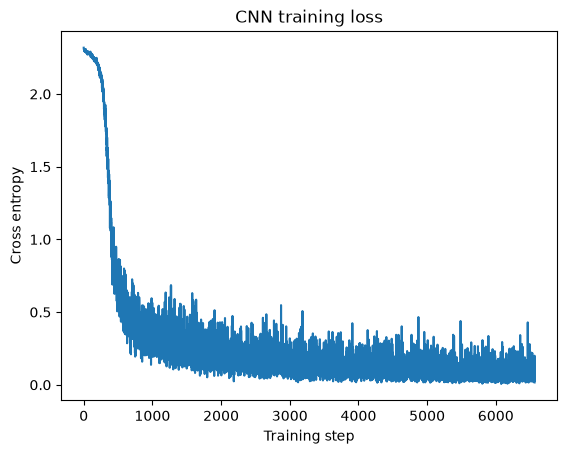

In [17]:
num_batches = len(trainset_loader)

for epoch in range(epochs):
    for batch_idx, (images, labels) in enumerate(trainset_loader):
        # Move to GPU
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = cnn_model(images)

        # Optimizer zero grad
        optimizer.zero_grad()

        # Loss
        loss = loss_function(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Record and plot loss
        loss_values.append(loss.item())
    print(f"CNN epoch {epoch + 1} loss: {np.mean(loss_values[-num_batches:]):.4f}")

# Record the final model metric: accuracy
cnn_model.eval()
correct_pred = 0
total_pred = 0
with torch.no_grad():
    for images, labels in testset_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        predicted = torch.argmax(outputs, dim=1)
        correct_pred += (predicted == labels).sum().item()
        total_pred += labels.size(0)

accuracy = correct_pred / total_pred
print(f"Final Test Accuracy: {accuracy:.4f}")
comet_model_2.log_metric("accuracy", accuracy)
comet_model_2.end()

plt.figure()
plt.plot(loss_values)
plt.xlabel("Training step")
plt.ylabel("Cross entropy")
plt.title("CNN training loss")
plt.show()


### My note on the loss curve

I plot the recorded loss after training so the notebook keeps a stable figure. I look for a downward trend and compare the final test result with the dense baseline rather than judging the curve alone.

In [18]:
# Evaluate the CNN model on the test dataset
test_loss, test_acc_cnn = evaluate(cnn_model, testset_loader, loss_function)
print('Test loss:', test_loss, 'Test accuracy:', test_acc_cnn)


Test loss: 0.0783001704249531 Test accuracy: 0.9738


In [19]:
# Obtain a single batch of test images
images, labels = next(iter(testset_loader))
images = images.to(device)

# Make predictions on the test images
predictions = cnn_model(images)
predictions_test_image = predictions[0]
print(predictions_test_image)


tensor([  0.2916,  -2.7308,   5.4957,   5.0845,  -5.5793,  -1.9437, -13.6337,
         14.0351,   1.1328,   3.2753], device='cuda:0',
       grad_fn=<SelectBackward0>)


## Reading a prediction

The ten values below are logits. The largest score gives the predicted digit. I only apply softmax when I want to display probabilities.

In [20]:
# identify the digit with the highest likelihood prediction for the first
# image in the test dataset.
predictions_value = predictions_test_image.cpu().detach().numpy() #.cpu() to copy tensor to memory first
prediction = np.argmax(predictions_value)
print(prediction)


7


I compare the prediction with the true label of the same test image. Matching the image index matters more than how confident the model sounds.

Label of this digit is: 7


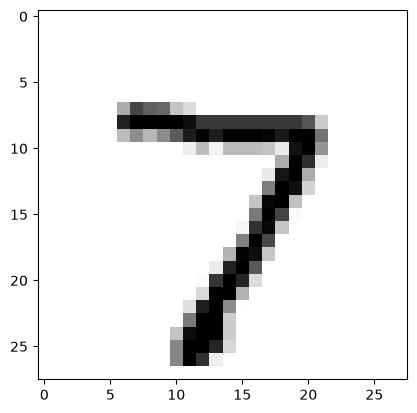

In [21]:
test_image, test_label = test_dataset[0]
print("Label of this digit is:", test_label)
plt.imshow(test_image.squeeze(), cmap=plt.cm.binary)
comet_model_2.log_figure(figure=plt)


### My note on mistakes

A high accuracy can still hide ambiguous handwriting. I inspect individual predictions to see whether the model confuses similar strokes or makes confident errors.

In [22]:
# Initialize variables to store all data
all_predictions = []
all_labels = []
all_images = []

# Process test set in batches
with torch.no_grad():
    for images, labels in testset_loader:
        images = images.to(device)
        outputs = cnn_model(images)

        # Apply softmax to get probabilities from the predicted logits
        probabilities = torch.nn.functional.softmax(outputs, dim=1)

        all_predictions.append(probabilities)
        all_labels.append(labels)
        all_images.append(images)

all_predictions = torch.cat(all_predictions)  # Shape: (total_samples, num_classes)
all_labels = torch.cat(all_labels)            # Shape: (total_samples,)
all_images = torch.cat(all_images)            # Shape: (total_samples, 1, 28, 28)

# Convert tensors to NumPy for compatibility with plotting functions
predictions = all_predictions.cpu().numpy()  # Shape: (total_samples, num_classes)
test_labels = all_labels.numpy()             # Shape: (total_samples,)
test_images = all_images.cpu().numpy()       # Shape: (total_samples, 1, 28, 28)


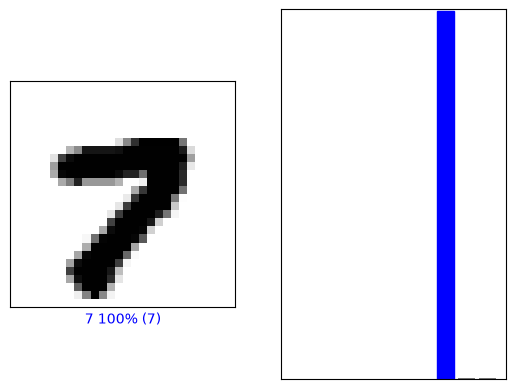

In [23]:
#@title Change the slider to look at the model's predictions! { run: "auto" }

image_index = 79 #@param {type:"slider", min:0, max:100, step:1}
plt.subplot(1,2,1)
mdl.lab2.plot_image_prediction(image_index, predictions, test_labels, test_images)
plt.subplot(1,2,2)
mdl.lab2.plot_value_prediction(image_index, predictions, test_labels)
comet_model_2.log_figure(figure=plt)


## Inspecting several predictions

I show each image beside its class probabilities. The course plotting helper colours the prediction to indicate whether it matches the label.

Recorded metrics: {'accuracy': 0.9738}


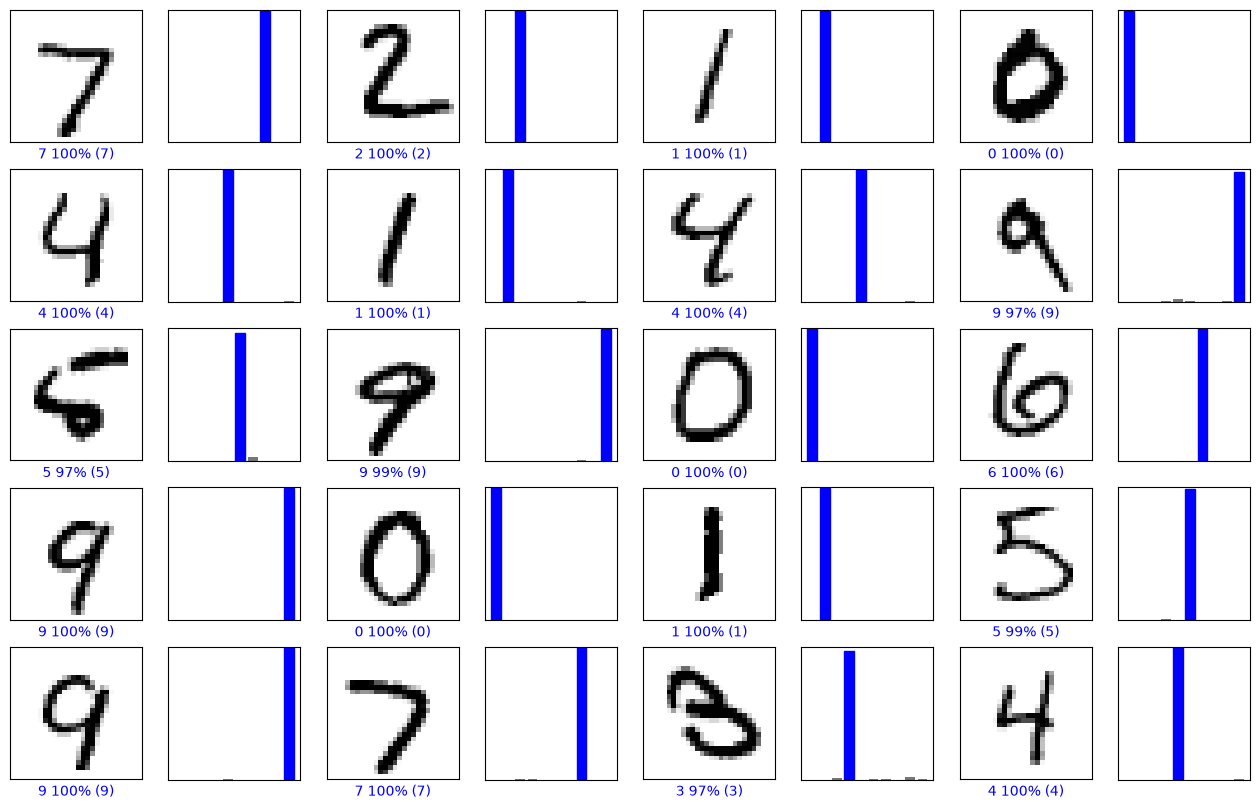

In [24]:
# Plots the first X test images, their predicted label and the true label
# Color correct predictions in blue, incorrect predictions in red
num_rows = 5
num_cols = 4
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    mdl.lab2.plot_image_prediction(i, predictions, test_labels, test_images)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    mdl.lab2.plot_value_prediction(i, predictions, test_labels)
comet_model_2.log_figure(figure=plt)
comet_model_2.end()


## What I take from this comparison

The dense model is a useful baseline and the CNN adds a preference for local image structure. The saved outputs show what happened in this run. I would need repeated runs and a validation split before claiming that one set of settings is best.